analysis -> feature engineering -> model

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [33]:
pd.set_option('display.max_columns',None)

In [ ]:
df = pd.read_csv('E:\credit_card_fraud\credit_card_fraud_imbalance.csv')
df

,Time,V1,V2,V3,V4,V5,Amount,Class
0,121958,-2.289061,-1.313758,-0.452562,-0.392802,0.224787,1600.89,0
1,146867,1.432482,-1.095302,-0.129910,-1.362911,-1.017335,4191.85,0
2,131932,1.214722,-0.168797,0.581433,0.699020,0.964415,3271.32,0
3,103694,-0.880864,0.110956,-0.203236,-0.243510,0.362543,1377.51,0
4,119879,-0.881879,0.786970,1.110118,0.015365,-1.135162,4838.72,0
...,...,...,...,...,...,...,...,...
995,150168,-0.239297,-0.093612,0.674449,-1.934307,0.201932,1863.34,0
996,67728,-0.717823,0.704535,0.347665,0.158832,-0.295808,1152.10,0
997,165088,-0.484361,1.489765,-0.921505,-0.624253,1.588061,2805.25,0
998,11246,1.053057,-0.885100,-0.391480,0.000222,-0.077757,672.88,0


In [35]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'Amount', 'Class'], dtype='object')

In [5]:
df['Amount'].describe()

,Amount
count,1000.000000
mean,2577.052080
std,1444.284318
min,25.890000
25%,1358.502500
50%,2636.405000
75%,3849.640000
max,4998.710000


In [36]:
print('Missing values in each column:')
print(df.isnull().sum())
num_duplicates = df.duplicated().sum()
print('Number of duplicate rows:', num_duplicates)


Missing values in each column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
Amount    0
Class     0
dtype: int64
Number of duplicate rows: 0


In [37]:
corr = df[['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'Amount', 'Class']].corr()


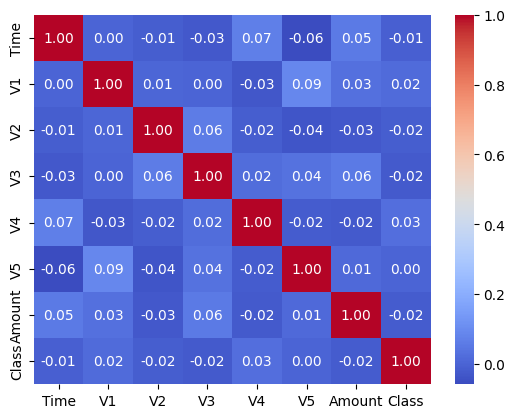

In [38]:
sns.heatmap(corr, annot=True, cmap='coolwarm',fmt='.2f')
plt.show()

<Figure size 800x500 with 0 Axes>

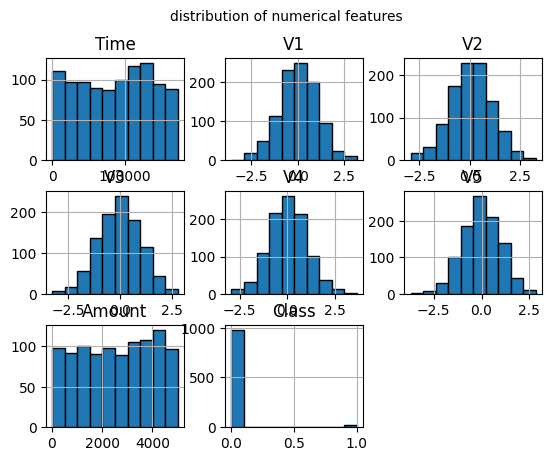

In [39]:
plt.figure(figsize=(8,5))
df[['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'Amount', 'Class']].hist(bins=10, edgecolor = 'black')
plt.suptitle('distribution of numerical features', fontsize = 10)
plt.show()

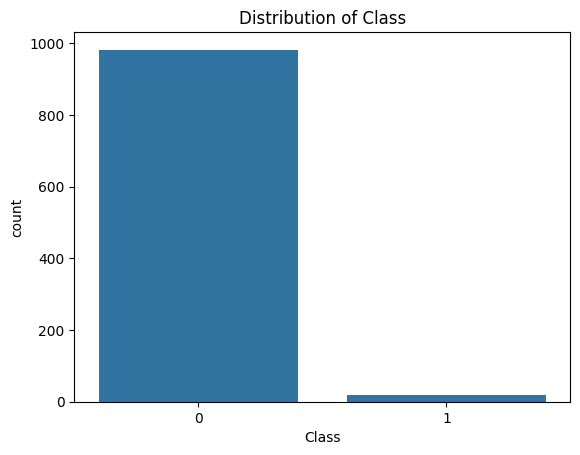

In [40]:
sns.countplot(x='Class', data= df)
plt.title('Distribution of Class')
plt.show()

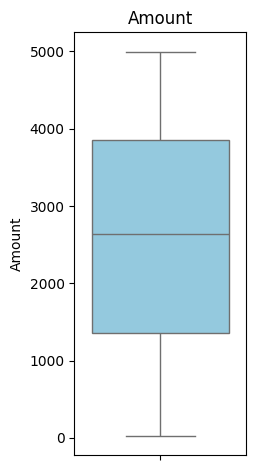

In [41]:
for i, col in enumerate(['Amount']):
    plt.subplot(1,3,i+1)
    sns.boxplot(y = df[col], color='skyblue')
    plt.title(col)
plt.tight_layout()
plt.show()

In [ ]:
# z score outlier detection
from scipy.stats import zscore, norm
alpha = 0.05
confidence = 1 - alpha
critical_z = norm.ppf(1 - alpha/2)
print(critical_z)



1.959963984540054


In [43]:
df['Z_score'] = zscore(df['Amount'])
df_filtered = df[df["Z_score"].abs() <= critical_z]

In [44]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
df_filtered[[ 'Amount']] = scaler.fit_transform(df_filtered[['Amount']])

In [45]:
df_filtered.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'Amount', 'Class', 'Z_score'], dtype='object')

In [51]:
features = df_filtered.drop(columns=['Amount','Z_score'])
features.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'Class'], dtype='object')

In [52]:
from sklearn.model_selection import train_test_split
x = features
y = df_filtered['Class']
X_train, X_test, y_train, y_test = train_test_split( x,y, test_size=0.2,random_state=42, stratify=y)

In [53]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under=rus.fit_resample(X_train, y_train)

In [54]:
print(y_train.value_counts())

Class
0    786
1     14
Name: count, dtype: int64


In [55]:
print(y_train_under.value_counts())

Class
0    14
1    14
Name: count, dtype: int64


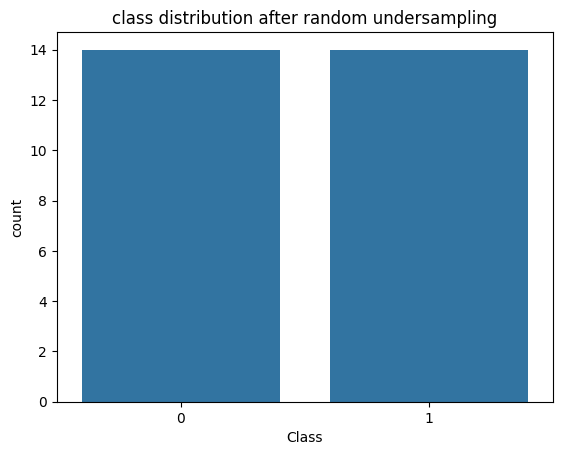

In [56]:
sns.countplot(x=y_train_under)
plt.title('class distribution after random undersampling')
plt.show()

In [59]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_under, y_train_under)
y_pred_lr = lr.predict(X_test)

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score,confusion_matrix
f1 = f1_score(y_test, y_pred_lr)
rs = recall_score(y_test, y_pred_lr)
ps = precision_score(y_test, y_pred_lr)
acc = accuracy_score(y_test,y_pred_lr)
cm = confusion_matrix(y_test, y_pred_lr)
roc_auc = roc_auc_score(y_test, y_pred_lr)
print('f1_score',f1)
print('Confusion matrix',cm)
print('recall',rs)
print('precision',ps)
print('accuracy',acc)
print('roc_auc',roc_auc)

f1_score 1.0
Confusion matrix [[196   0]
 [  0   4]]
recall 1.0
precision 1.0
accuracy 1.0
roc_auc 1.0


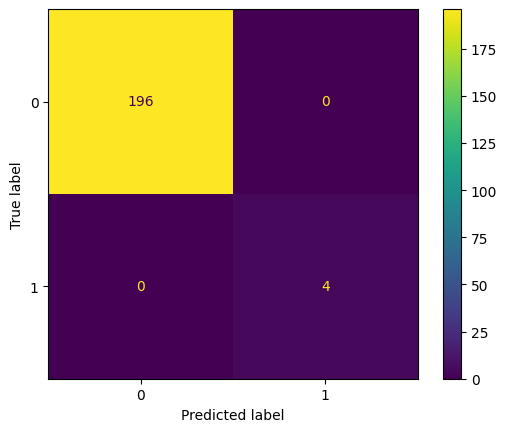

In [63]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test)
plt.show()

In [57]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=62, criterion='gini', class_weight='balanced')
model.fit(X_train_under, y_train_under)
y_pred = model.predict(X_test)

In [ ]:

f1_score(y_test, y_pred)
rs = recall_score(y_test, y_pred)
ps = precision_score(y_test, y_pred)
acc = accuracy_score(y_test,y_pred)
roc_auc = roc_auc_score(y_test,y_pred)
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(rs)
print(ps)
print(acc)
print(roc_auc)

[[196   0]
 [  0   4]]
1.0
1.0
1.0
1.0


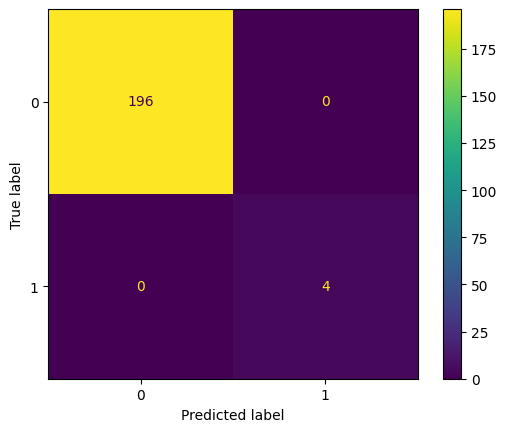

In [64]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.show()

In [65]:
def calculate_iv(df, feature, target, bins=10):
    data = df[[feature, target]].copy()

    data['bin'] = pd.qcut(data[feature], q=bins, duplicates='drop')

    grouped = data.groupby('bin', as_index=False)

    iv_df = pd.DataFrame()
    iv_df['bin'] = [str(b) for b in grouped.groups.keys()]
    iv_df['total'] = grouped.count()[target].values
    iv_df['events'] = grouped.sum()[target].values # Fraud (Class = 1)
    iv_df['non_events'] = iv_df['total'] - iv_df['events'] # Legit (Class = 0)

    total_events = iv_df['events'].sum()
    total_non_events = iv_df['non_events'].sum()

    iv_df['pct_events'] = (iv_df['events'] + 0.0001) / (total_events + 0.0001)
    iv_df['pct_non_events'] = (iv_df['non_events'] + 0.0001) / (total_non_events + 0.0001)

    iv_df['WOE'] = np.log(iv_df['pct_non_events'] / iv_df['pct_events'])
    iv_df['IV'] = (iv_df['pct_non_events'] - iv_df['pct_events']) * iv_df['WOE']

    total_iv = iv_df['IV'].sum()

    return total_iv, iv_df

In [67]:
calculate_iv(df_filtered, feature = 'V1',target = 'Class', bins=10)

/tmp/ipykernel_1041/3022902697.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby('bin', as_index=False)


(np.float64(3.454961547416077),
                 bin  total  events  non_events  pct_events  pct_non_events  \
 0  (-3.569, -1.318]    100       0         100    0.000006        0.101833   
 1  (-1.318, -0.795]    100       1          99    0.055561        0.100815   
 2  (-0.795, -0.522]    100       2          98    0.111116        0.099796   
 3  (-0.522, -0.241]    100       6          94    0.333337        0.095723   
 4  (-0.241, 0.0314]    100       2          98    0.111116        0.099796   
 5   (0.0314, 0.278]    100       0         100    0.000006        0.101833   
 6     (0.278, 0.56]    100       1          99    0.055561        0.100815   
 7     (0.56, 0.902]    100       0         100    0.000006        0.101833   
 8    (0.902, 1.325]    100       4          96    0.222227        0.097760   
 9    (1.325, 3.174]    100       2          98    0.111116        0.099796   
 
         WOE        IV  
 0  9.816297  0.999569  
 1  0.595807  0.026963  
 2 -0.107443  0.001216